In [1]:
"""
Implement better simulations using frequency domain interpolation
"""

'\nImplement better simulations using frequency domain interpolation\n'

In [3]:
import numpy as np
from util.DataGen import nai_pulse, sample_shift_to_phase_shift, continuous_time_trace
import scipy
import matplotlib.pyplot as plt
import tqdm

Pulse Peak Offset: 9


(500.0, 600.0)

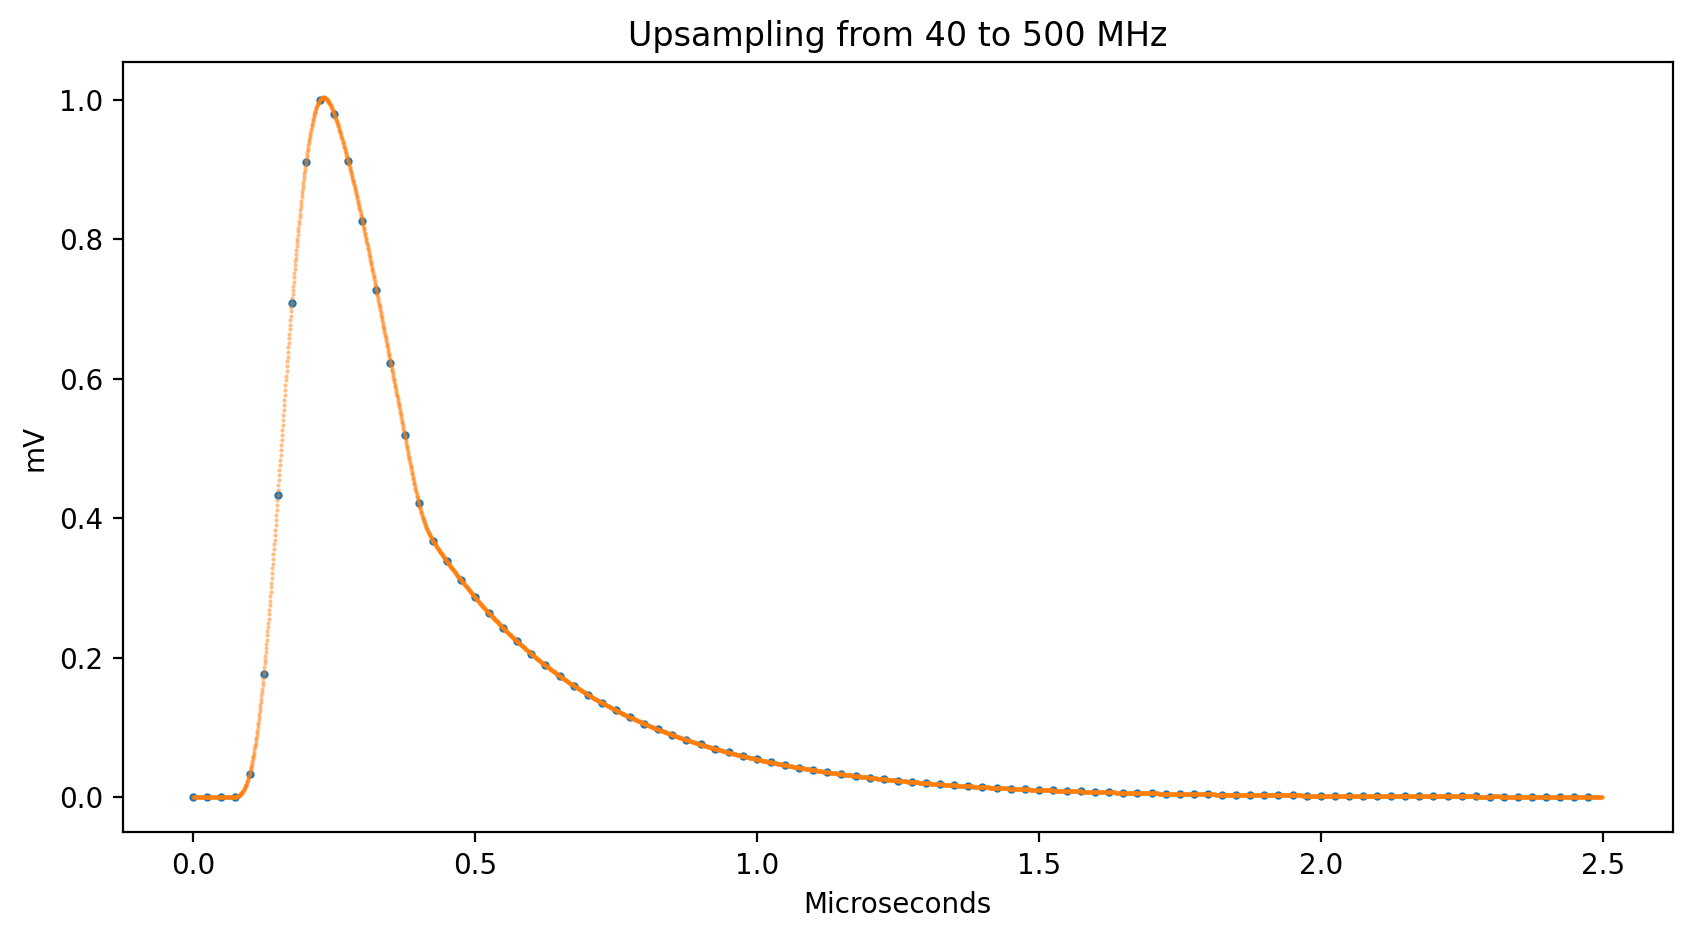

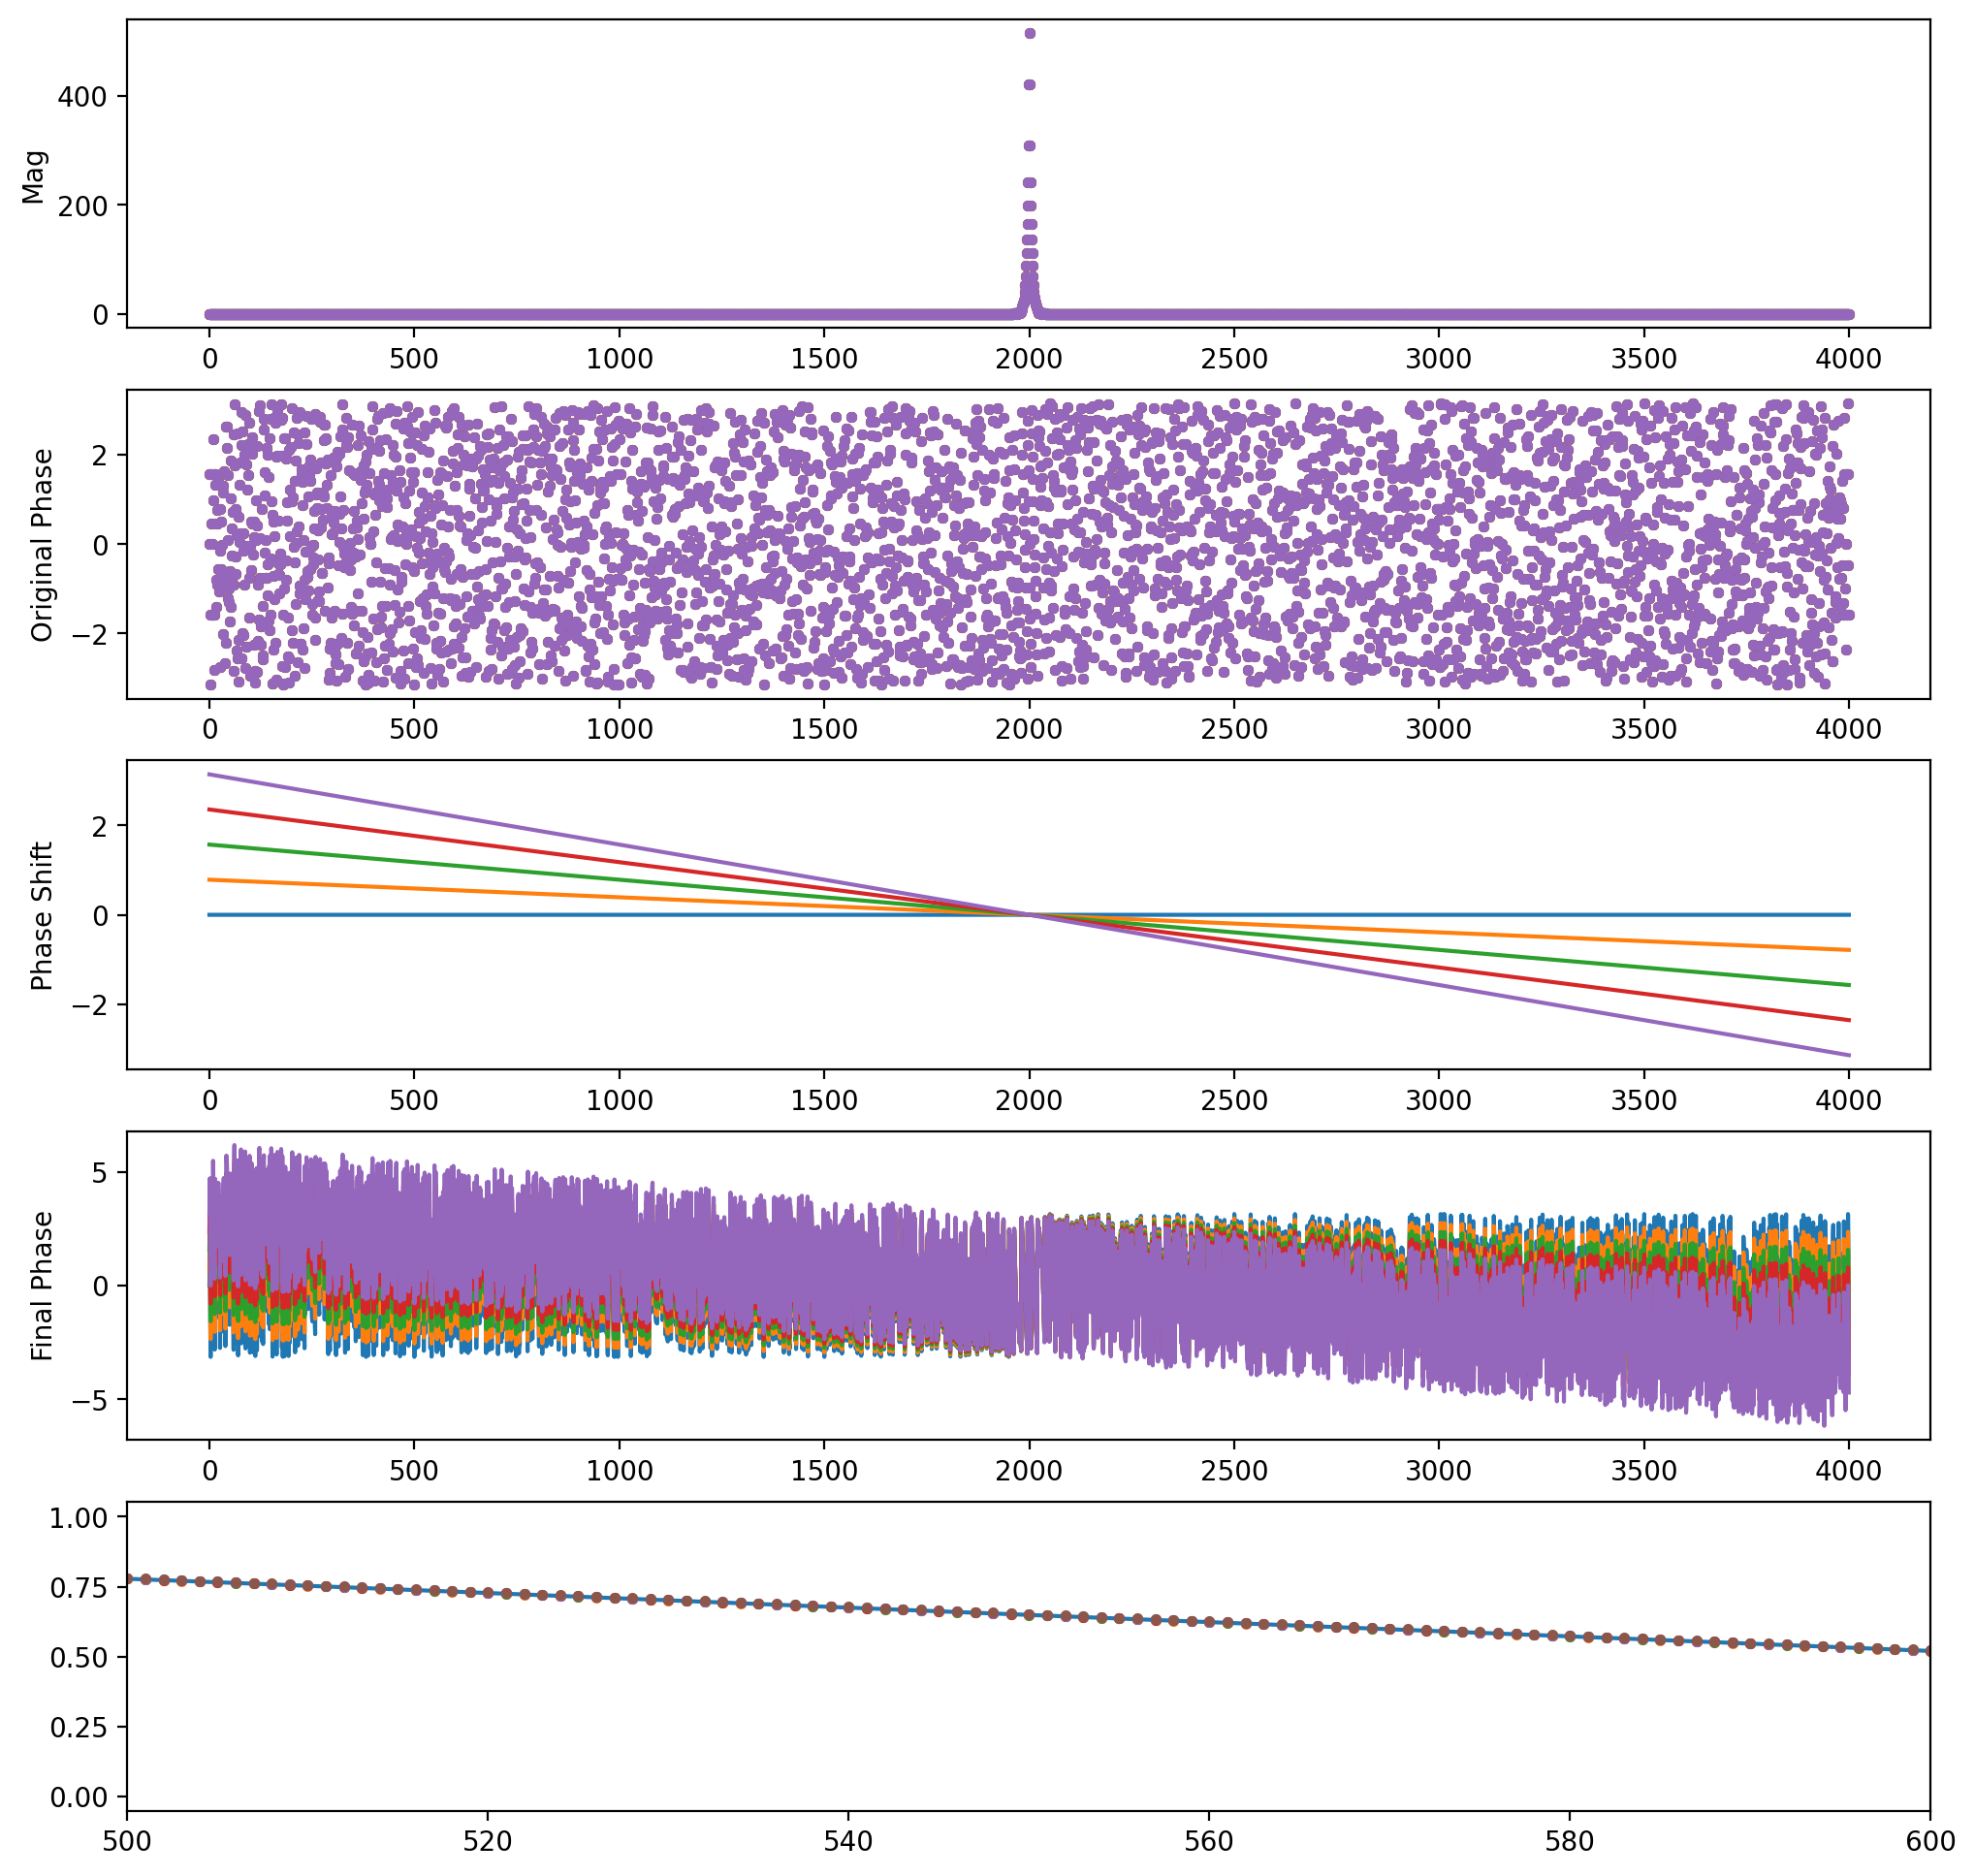

In [4]:
pulse_times, pulse = nai_pulse(1)
pulse_times = pulse_times[:-1]
pulse = pulse[:-1]
print('Pulse Peak Offset:', np.argmax(pulse))

fig,axes = plt.subplots(1,1, figsize=(10,5), dpi=200)
axes.plot(1E6*pulse_times, pulse, '.', markersize=4)

n_pulse = pulse.size
interp_pulse, interp_time = scipy.signal.resample(pulse, t=pulse_times, num=n_pulse*500)
interp_pulse, interp_time = scipy.signal.resample(interp_pulse, t=interp_time, num=n_pulse*40)

# interp_pulse, interp_time = scipy.signal.resample(pulse, t=pulse_times, num=n_pulse)

axes.plot(1E6*interp_time, interp_pulse, '.', markersize=1, alpha=.5)
axes.set_xlabel('Microseconds')
axes.set_title('Upsampling from 40 to 500 MHz')
axes.set_ylabel('mV')

del pulse_times, pulse # make sure we are not using them


pulse = np.concatenate((np.zeros(interp_pulse.size), interp_pulse[:100], np.zeros(interp_pulse.size)))
# pulse = np.concatenate((np.zeros(100), pulse, np.zeros(100)))
base_time = np.arange(interp_pulse.size)
z = scipy.fft.fft(interp_pulse)

shifts = np.linspace(0, 1, 5)

fig, axes = plt.subplots(5, 1, figsize=(12,12), dpi=200)
axes[4].plot(base_time, interp_pulse, label='original')
    
for t_shift in shifts:
    mag, angle, whole_fft_spectrum_phase_shift, phase_shifted, complex_shifted = sample_shift_to_phase_shift(t_shift, z, return_extra=True)
    td_phase_shifted = np.real(scipy.fft.ifft(complex_shifted))

    axes[0].plot(mag, '.', label=t_shift)
    axes[1].plot(angle, '.', label=t_shift)
    axes[2].plot(whole_fft_spectrum_phase_shift, label=t_shift)
    axes[3].plot(phase_shifted, label=t_shift)
    axes[4].plot(base_time, td_phase_shifted, '.', label=t_shift)

axes[0].set_ylabel('Mag')
axes[1].set_ylabel('Original Phase')
axes[2].set_ylabel('Phase Shift')
axes[3].set_ylabel('Final Phase')
# axes[4].set_xlim(50, 175)
axes[4].set_xlim(500, 600)

# https://wirelesspi.com/effect-of-time-shift-in-frequency-domain/


50
Trace Size: 5101


Text(0.5, 0, 'Microseconds')

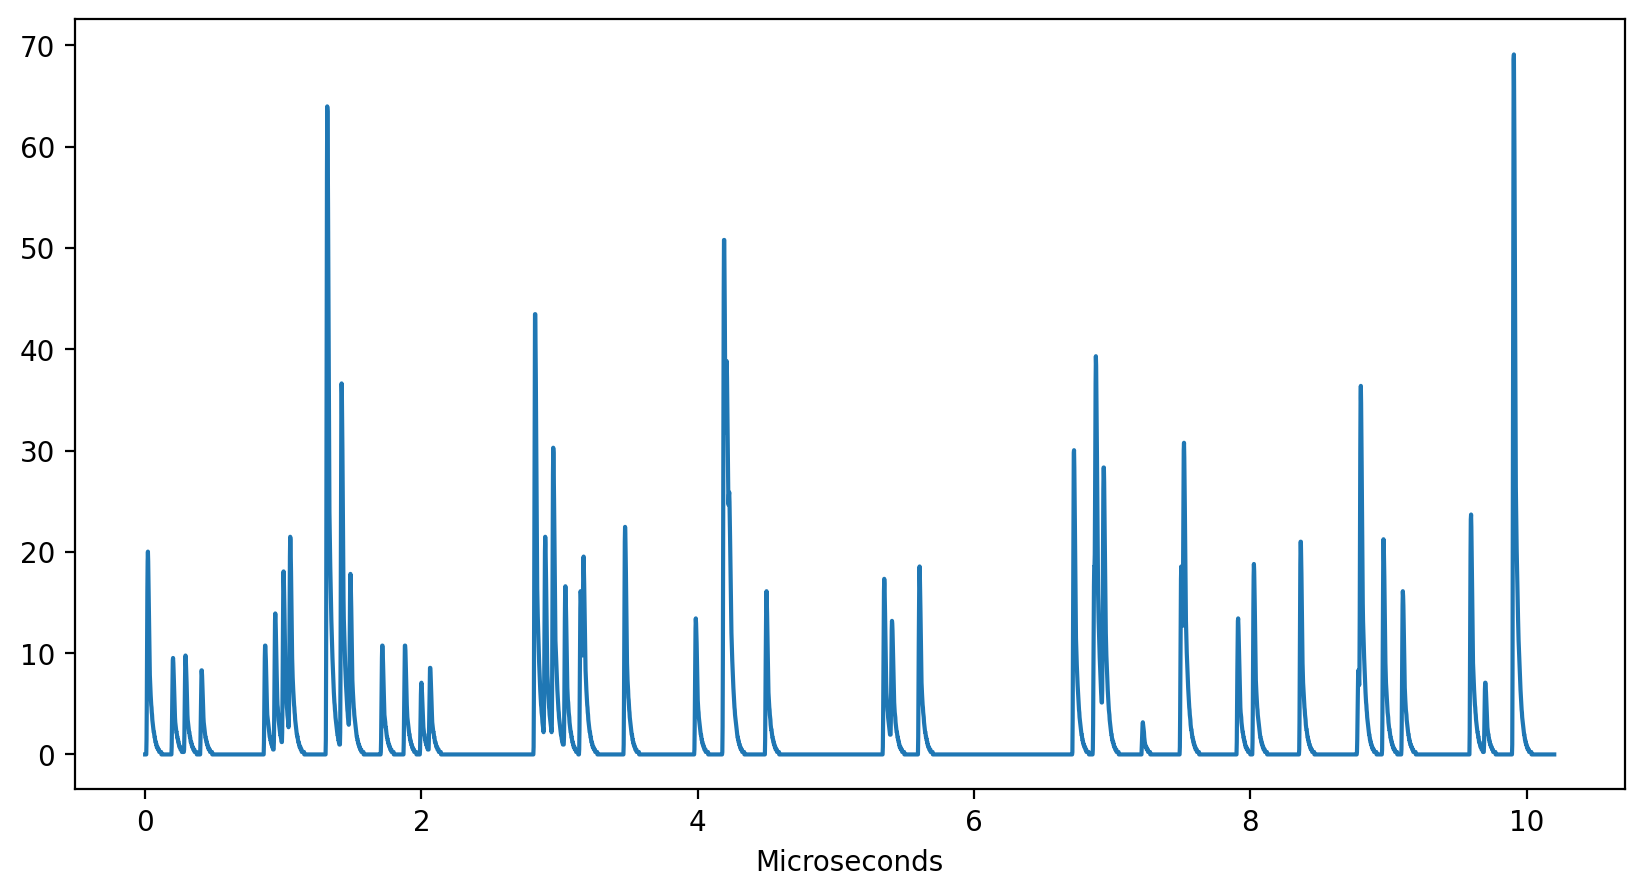

In [5]:
_, pulse = nai_pulse(1)
keV_per_area = .147 #determined by trial and error to match energy range of instrument 
mV_per_ADC = 1000./4096.
baseline = 100
basenoise = 1 #units mV
fs = 500E6 # new HERA sampling rate?
bits = 12

# for Lognormal traces
fwhm = 50 #50.0 #fwhm of the total TGF count distribution in units microseconds
mean = .007 #.7 #mean of the TGF trace distribution
std = .5 #.5 #determines the amount of assymetry in the TGF trace distribution

response_file = 'original/NaI_Response'
spectrum = np.loadtxt(response_file,usecols=(1),dtype=float) # histogram density, unitless
binenergies = np.loadtxt(response_file,usecols=(0),dtype=float) *1e3 # [KeV]

out = continuous_time_trace(pulse, binenergies, spectrum, mV_per_ADC, keV_per_area,
                            fs=fs, count_rate=5E6, total_time=1E-5, trace_type='constant',
                            lognormal_mean=mean, lognormal_std=std, lognormal_fwhm=fwhm,
                            baseline=basenoise, basenoise=basenoise, bits=bits, seed=1)

sample_t, sample_index, trace, event_voltages, event_energies = out

print('Trace Size:', trace.size)

plt.figure(figsize=(10,5), dpi=200)
plt.plot(1E6*sample_t, trace)
plt.plot()
plt.xlabel('Microseconds')
# plt.xlim(17.5, 18)
# plt.xlim(1, 6)
# ply.ylim

# plt.plot(sample_index, trace)
# plt.xlim(0, 4000)